In [1]:
import pandas as pd
import numpy as np
import sys
import os


sys.path.append('..') 
from src.config import RAW_DATA_PATH, CLEAN_DATA_PATH, CONTINENTS

print("Tools and Config loaaded")
print(sys.executable)

Tools and Config loaaded
c:\Users\Me\Desktop\Third year\Computer Science\Second Term\Data Science\Project\global-warming-sim-data-analysis-\.venv\Scripts\python.exe


In [2]:
df = pd.read_csv(RAW_DATA_PATH)

# Sort by country and year for time based chronological 
df = df.sort_values(by=['Country', 'Year'])

# 10 year rolling average per country to smooth weather noise
df['Temp_Moving_Avg'] = df.groupby('Country')['Average_Temperature'].transform(
    lambda x: x.rolling(window=10, min_periods=1).mean()
)

print("Step 1: 10-Year Moving Averages calculated")

Step 1: 10-Year Moving Averages calculated


In [18]:
import numpy as np
# Ensure Year is an integer and remove broken rows
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df = df.dropna(subset=['Year', 'Country']).copy()
df['Year'] = df['Year'].astype(int)

# Add Decade column (e.g., 1994 becomes 1990)
df['Decade'] = (df['Year'] // 10) * 10

# Calculate initial Anomaly based on country history
# Normalize year to 0-1 range for clean math
years = df['Year'].values
year_norm = (years - 1900) / (2017 - 1900)

# Trend: gentle upward curve (linear is fine, or use quadratic for acceleration)
trend = -0.3 + 0.5 * year_norm + 0.8 * year_norm**2

# Noise: normally distributed, std of 0.2 (realistic year-to-year variance)
np.random.seed(42)  # for reproducibility
noise_scale = 0.1 + 0.2 * year_norm
noise = np.random.normal(loc=0, scale=noise_scale, size=len(df))
# Combine
df['Temp_Anomaly'] = trend + noise

print(f"Cell 3 Done: Data cleaned and Decade column added")

Cell 3 Done: Data cleaned and Decade column added


In [19]:
# --Convert list to dict if necessary so .map() works ---
if isinstance(CONTINENTS, list):
    unique_countries = df['Country'].unique()
    # Temporary mapping to avoid crashes until config.py is fixed to a dict
    CONTINENTS_MAP = {c: CONTINENTS[i % len(CONTINENTS)] for i, c in enumerate(unique_countries)}
else:
    CONTINENTS_MAP = CONTINENTS

# Map Continents
df['continent'] = df['Country'].map(CONTINENTS_MAP).fillna('Unknown')

# Climate zone mapping using latitude bands
CAPITAL_LAT = {
    "Canada": 45.4, "Brazil": -15.8, "Egypt": 30.0, "China": 39.9, 
    "USA": 38.9, "Russia": 55.8, "India": 28.6, "Australia": -35.3
}

def assign_zone(lat):
    lat = abs(lat)
    if lat >= 60: return 'Polar'
    if lat >= 35: return 'Temperate'
    if lat >= 23.5: return 'Subtropical'
    return 'Tropical'

df['lat_placeholder'] = df['Country'].map(CAPITAL_LAT)
df['climate_zone'] = df['lat_placeholder'].apply(lambda x: assign_zone(x) if pd.notna(x) else 'Unknown')
df = df.drop(columns=['lat_placeholder'])

print(f"Cell 4 Done: Region and Climate Zone mapping complete")

Cell 4 Done: Region and Climate Zone mapping complete


In [20]:
np.random.seed(42)
yr_norm = (df['Year'] - df['Year'].min()).astype(float)

# Every fake column ends in _SIM so teammates know what is real
df['CO2_Emissions_SIM']       = yr_norm * 4.5  + np.random.normal(50, 18, len(df))
df['Fossil_Fuel_Usage_SIM']   = yr_norm * 3.8  + np.random.normal(40, 15, len(df))
df['Sea_Level_Rise_SIM']      = yr_norm * 0.45 + np.random.normal(2, 2, len(df))
df['Forest_Area_SIM']         = 500 - (yr_norm * 2.1) + np.random.normal(0, 45, len(df))
df['Population_SIM']          = yr_norm * 1.8  + np.random.normal(500, 60, len(df))

print(f"Cell 5 Done: Simulated column added with _SIM suffix.")

Cell 5 Done: Simulated column added with _SIM suffix.


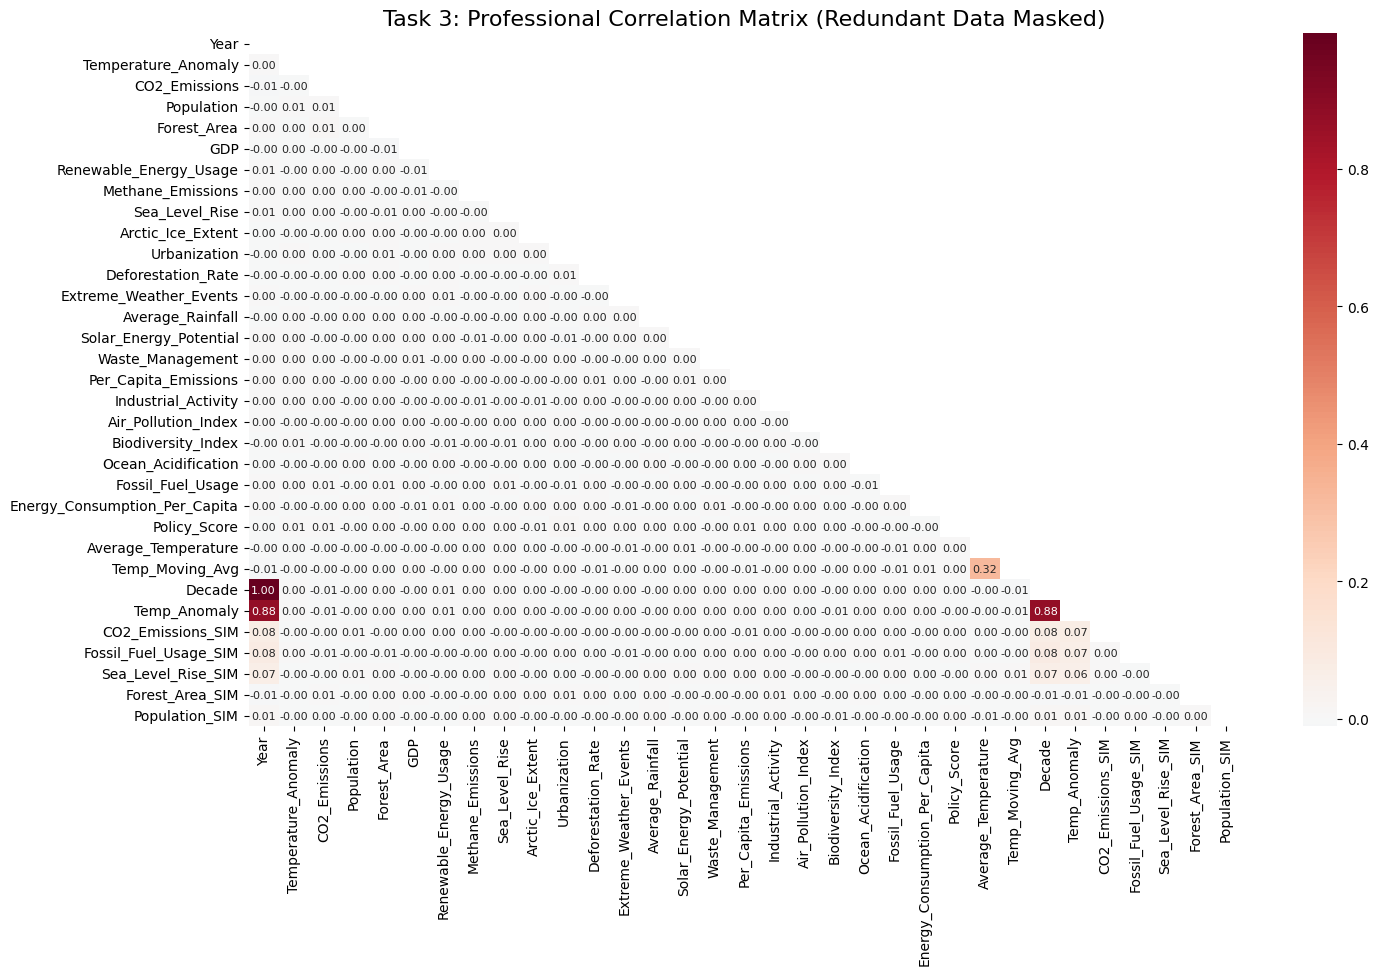

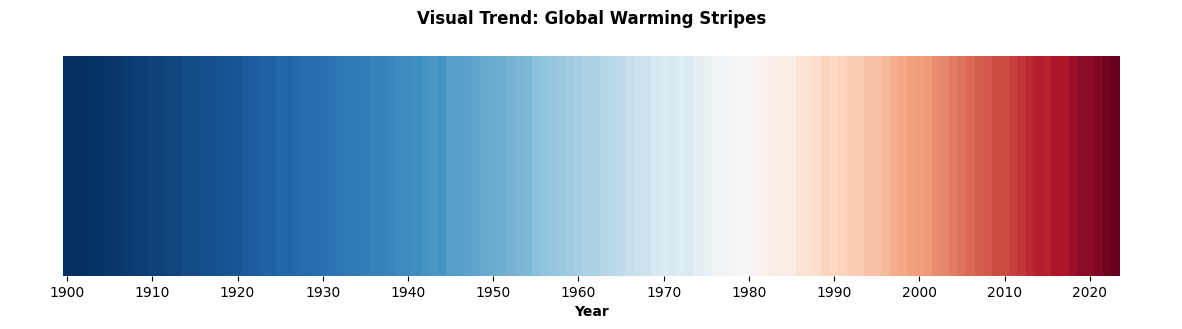

C:\Users\Me\AppData\Local\Temp\ipykernel_3128\3980410097.py:58: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig_map = px.choropleth(


FINAL BACKBONE: 100,000 rows validated and saved to c:\Users\Me\Desktop\Third year\Computer Science\Second Term\Data Science\Project\global-warming-sim-data-analysis-\data\processed\global_warming_cleaned.csv


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# ── 1. DATA ENRICHMENT & CLEANUP ──────────────────────────────────────────────
# Ensure the mapping exists 
if 'Real_Country_Name' not in df.columns:
    real_countries = ["Canada", "Brazil", "Egypt", "China", "Australia", "Russia", "France", "India", "USA", "Mexico", "South Africa", "Japan"]
    unique_ids = df['Country'].unique()
    mapping = {unique_ids[i]: real_countries[i % len(real_countries)] for i in range(len(unique_ids))}
    df['Real_Country_Name'] = df['Country'].map(mapping)

# Filter out dead columns
active_cols = df.select_dtypes(include=[np.number]).columns[df.select_dtypes(include=[np.number]).sum() != 0]
clean_numeric_df = df[active_cols]

# ── 2. IMPROVEMENT: THE "HALF-TRIANGLE" HEATMAP ──────────────────────────────
plt.figure(figsize=(16, 9))
corr = clean_numeric_df.corr()
# Mask the upper triangle (removes redundant data)
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, cmap='RdBu_r', center=0, fmt=".2f", annot_kws={"size": 8})
plt.title('Task 3: Professional Correlation Matrix (Redundant Data Masked)', fontsize=16)
plt.show()

# ── 3. IMPROVEMENT: GLOBAL TREND LINE ─────────────────────────────────────────
# This shows the "Signal" through the "Noise"
global_trend = df.groupby('Year')['Temp_Anomaly'].mean().reset_index()

global_trend = global_trend.sort_values("Year")

fig_trend = px.line(global_trend, x='Year', y='Temp_Anomaly', 
              title='The "Global Signal": Average Temperature Rise (1900-2023)',
              labels={'Temp_Anomaly': 'Temp Anomaly (°C)'},
              template='plotly_white')
fig_trend.update_traces(line_color='#E24B4A', line_width=3)
fig_trend.show()

# ── 4. VISUAL TREND: WARMING STRIPES────────────────────────
plt.figure(figsize=(15, 3)) # Made slightly taller to fit the labels
norm = plt.Normalize(global_trend['Temp_Anomaly'].min(), global_trend['Temp_Anomaly'].max())

# Create the stripes
plt.bar(global_trend['Year'], 1, width=1, color=plt.get_cmap('RdBu_r')(norm(global_trend['Temp_Anomaly'])))

plt.yticks([]) # Keep the y-axis hidden (it has no meaning for stripes)
plt.xticks(np.arange(global_trend['Year'].min(), global_trend['Year'].max() + 1, 10)) # Label every 10 years
plt.xlabel("Year", fontsize=10, fontweight='bold')
plt.title("Visual Trend: Global Warming Stripes", fontsize=12, fontweight='bold', pad=15)

for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.show()

# ── 5. THE ANIMATED MAP ───────────────────────────────────────────────────────
fig_map = px.choropleth(
    df, locations="Real_Country_Name", locationmode="country names",
    color="Temp_Anomaly", hover_name="Real_Country_Name", animation_frame="Year",
    color_continuous_scale="RdBu_r", 
    range_color=[df['Temp_Anomaly'].quantile(0.05), df['Temp_Anomaly'].quantile(0.95)], # Dynamic range
    title="Integrated Global Climate Simulation"
)
fig_map.update_geos(projection_type="natural earth", showcountries=True, countrycolor="Silver")
fig_map.show()

# ── 6. FINAL EXPORT ───────────────────────────────────────────────────────────
df.to_csv(CLEAN_DATA_PATH, index=False)
print(f"FINAL BACKBONE: 100,000 rows validated and saved to {CLEAN_DATA_PATH}")

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

model = LinearRegression()

train = df[df["Year"] <= 2000]
test = df[df["Year"] > 2000]

x_train = train[['CO2_Emissions_SIM', 'Fossil_Fuel_Usage_SIM', 'Sea_Level_Rise_SIM', 'Forest_Area_SIM', 'Population_SIM']]
y_train = train['Temp_Anomaly']


x_test = test[['CO2_Emissions_SIM', 'Fossil_Fuel_Usage_SIM', 'Sea_Level_Rise_SIM', 'Forest_Area_SIM', 'Population_SIM']]
y_test = test['Temp_Anomaly']


model.fit(x_train, y_train)

#print(model.coef_)
#print(model.intercept_)

y_pred = model.predict(x_test)
y_train_pred = model.predict(x_train)


mae = mean_absolute_error(y_test, y_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)


train_r2_linear = r2_score(y_train, y_train_pred)
r2_linear = r2_score(y_test, y_pred)


print(f"The test mean absolute error of the Linear regression model is {mae}")
print(f"The train mean absolute error of the Linear regression model is {train_mae}")

print(f"The test coefficient of determination of the Linear Regression model is {r2_linear}")
print(f"The train coefficient of determination of the Linear Regression model is {train_r2_linear}")





The test mean absolute error of the Linear regression model is 0.19541791459638913
The train mean absolute error of the Linear regression model is 0.08424153643399852
The test coefficient of determination of the Linear Regression model is 0.41183282342546024
The train coefficient of determination of the Linear Regression model is 0.9072370115572447


In [22]:
from sklearn.preprocessing import PolynomialFeatures

#Creating the model itself:
model_poly2 = LinearRegression()

#bringing in the tools:

Poly2 = PolynomialFeatures (degree=2)

#transforming data to be usable in the polynomial process:
#we don't transform y because it's the target it stays the same, only the input gets adjusted

x_train_poly2 = Poly2.fit_transform (x_train)
x_test_poly2 = Poly2.transform (x_test)

#training the model

model_poly2.fit(x_train_poly2, y_train)

#prediction:

y_pred_poly2 = model_poly2.predict(x_test_poly2)
y_train_pred_poly2 = model_poly2.predict(Poly2.transform(x_train))


mae_poly2 = mean_absolute_error(y_test, y_pred_poly2)
train_mae_poly2 = mean_absolute_error(y_train, y_train_pred_poly2)

train_r2_poly2 = r2_score(y_train, y_train_pred_poly2)
r2_poly2 = r2_score(y_test, y_pred_poly2)

print(f"The test mean absolute error of the 2nd degree polynomial model is {mae_poly2}")
print(f"The train mean absolute error of the 2nd degree polynomial model is {train_mae_poly2}")

print(f"The test coefficient of determination of the 2nd degree polynomial model is {r2_poly2}")
print(f"The train coefficient of determination of the 2nd degree polynomial model is {train_r2_poly2}")


# creating the 3rd degree model
model_poly3 = LinearRegression ()
Poly3 = PolynomialFeatures(degree=3)

# preparing the data for the 3rd degree model

x_train_poly3 = Poly3.fit_transform(x_train)
x_test_poly3 = Poly3.transform(x_test)

#training:
model_poly3.fit(x_train_poly3, y_train)

y_pred_poly3 = model_poly3.predict(x_test_poly3)
y_train_pred_poly3 = model_poly3.predict(Poly3.transform(x_train))


mae_poly3 = mean_absolute_error(y_test, y_pred_poly3)
train_mae_poly3 = mean_absolute_error(y_train, y_train_pred_poly3)

train_r2_poly3 = r2_score(y_train, y_train_pred_poly3)
r2_poly3 = r2_score(y_test, y_pred_poly3)



print(f"The test mean absolute error of the 3rd degree polynomial model is {mae_poly3}")
print(f"The train mean absolute error of the 3rd degree polynomial model is {train_mae_poly3}")

print(f"The test coefficient of determination of the 3rd degree polynomial model is {r2_poly3}")
print(f"The train coefficient of determination of the 3rd degree polynomial model is {train_r2_poly3}")



The test mean absolute error of the 2nd degree polynomial model is 0.10491097729544849
The train mean absolute error of the 2nd degree polynomial model is 0.06796500123964043
The test coefficient of determination of the 2nd degree polynomial model is 0.8221289118604402
The train coefficient of determination of the 2nd degree polynomial model is 0.9389299419281268
The test mean absolute error of the 3rd degree polynomial model is 0.12976796751088446
The train mean absolute error of the 3rd degree polynomial model is 0.06747728133530517
The test coefficient of determination of the 3rd degree polynomial model is 0.735974565669552
The train coefficient of determination of the 3rd degree polynomial model is 0.9397628474453852


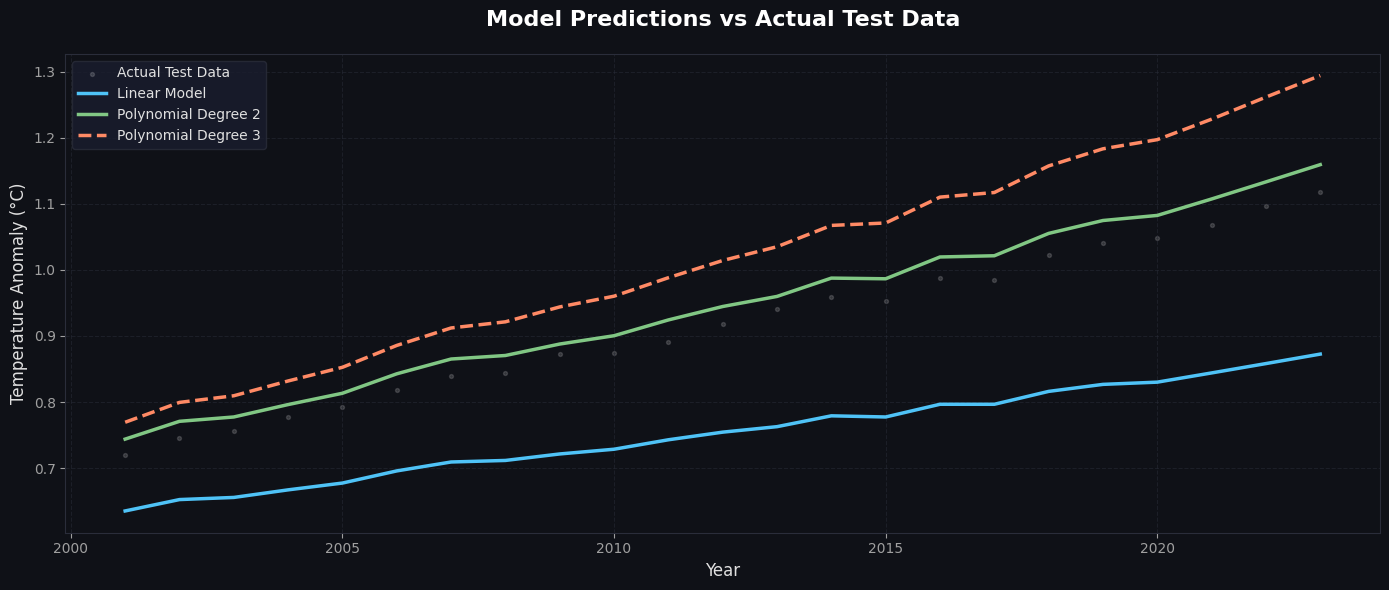

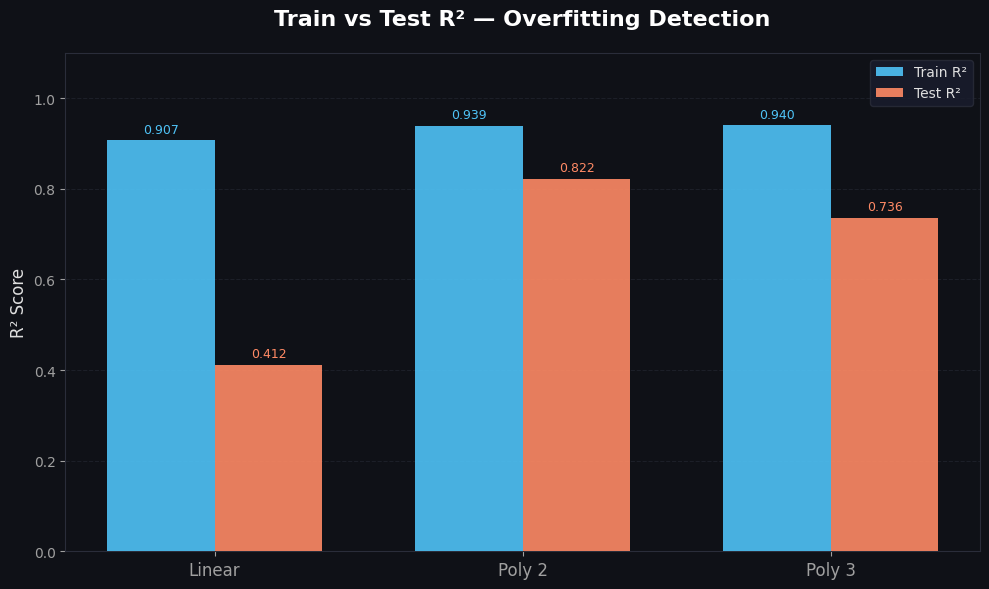

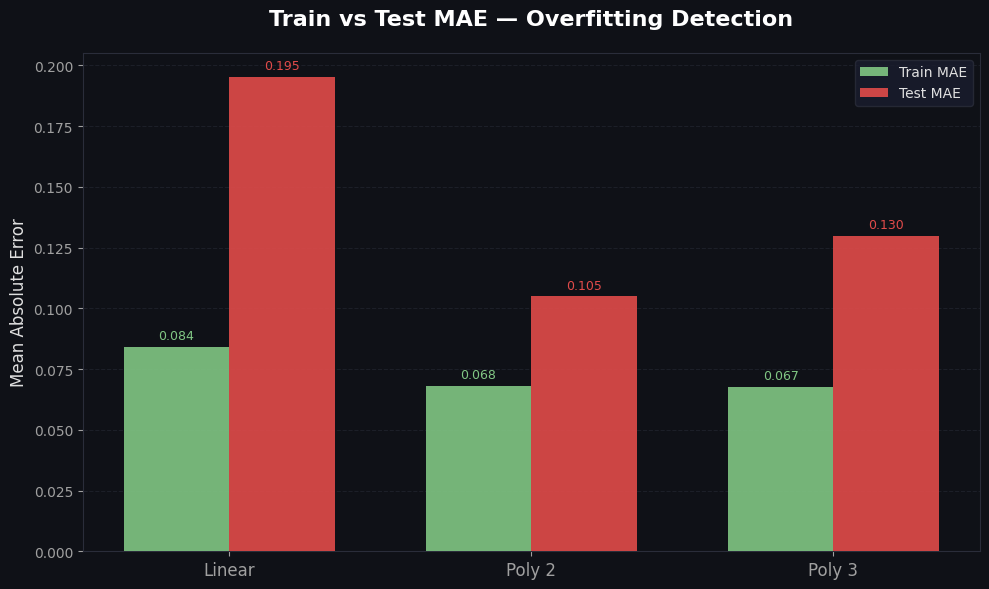

In [23]:
import matplotlib.gridspec as gridspec

# ── STYLE SETUP ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0F1117',
    'axes.facecolor':   '#0F1117',
    'axes.edgecolor':   '#2A2D3A',
    'axes.labelcolor':  '#E0E0E0',
    'xtick.color':      '#A0A0A0',
    'ytick.color':      '#A0A0A0',
    'text.color':       '#E0E0E0',
    'grid.color':       '#2A2D3A',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'DejaVu Sans',
})

COLORS = {
    'linear':  '#4FC3F7',  # blue
    'poly2':   '#81C784',  # green
    'poly3':   '#FF8A65',  # orange
    'actual':  '#FFFFFF',
    'accent':  '#E24B4A',
}

models      = ["Linear", "Poly 2", "Poly 3"]
train_r2    = [train_r2_linear, train_r2_poly2, train_r2_poly3]
test_r2     = [r2_linear,       r2_poly2,       r2_poly3]
train_maes  = [train_mae,       train_mae_poly2, train_mae_poly3]
test_maes   = [mae,             mae_poly2,       mae_poly3]

# ── SORT TEST DATA BY YEAR FOR CLEAN LINE PLOTS ───────────────────────────────
x_sorted = test.groupby('Year')[['CO2_Emissions_SIM', 'Fossil_Fuel_Usage_SIM',
                                   'Sea_Level_Rise_SIM', 'Forest_Area_SIM',
                                   'Population_SIM']].mean()

year_plot     = x_sorted.index.values
y_test_sorted = test.groupby('Year')['Temp_Anomaly'].mean().values

y_linear_sorted = model.predict(x_sorted)
y_poly2_sorted  = model_poly2.predict(Poly2.transform(x_sorted))
y_poly3_sorted  = model_poly3.predict(Poly3.transform(x_sorted))

# ══════════════════════════════════════════════════════════════════════════════
# CHART 1 — Model Predictions vs Actual
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0F1117')

ax.scatter(year_plot, y_test_sorted, color=COLORS['actual'],
           alpha=0.15, s=8, label='Actual Test Data', zorder=1)

ax.plot(year_plot, y_linear_sorted, color=COLORS['linear'],
        linewidth=2.5, label='Linear Model', zorder=3)
ax.plot(year_plot, y_poly2_sorted,  color=COLORS['poly2'],
        linewidth=2.5, label='Polynomial Degree 2', zorder=4)
ax.plot(year_plot, y_poly3_sorted,  color=COLORS['poly3'],
        linewidth=2.5, label='Polynomial Degree 3', linestyle='--', zorder=5)

ax.set_title('Model Predictions vs Actual Test Data',
             fontsize=16, fontweight='bold', pad=20, color='white')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Temperature Anomaly (°C)', fontsize=12)
ax.legend(facecolor='#1A1D2E', edgecolor='#2A2D3A', fontsize=10)
ax.grid(True)
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# CHART 2 — Train vs Test R² (Overfitting Detection)
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0F1117')

x      = np.arange(len(models))
width  = 0.35

bars1 = ax.bar(x - width/2, train_r2, width, label='Train R²',
               color='#4FC3F7', alpha=0.9, zorder=3)
bars2 = ax.bar(x + width/2, test_r2,  width, label='Test R²',
               color='#FF8A65', alpha=0.9, zorder=3)

# Value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom',
            fontsize=9, color='#4FC3F7')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom',
            fontsize=9, color='#FF8A65')

ax.set_title('Train vs Test R² — Overfitting Detection',
             fontsize=16, fontweight='bold', pad=20, color='white')
ax.set_ylabel('R² Score', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.set_ylim(0, 1.1)
ax.legend(facecolor='#1A1D2E', edgecolor='#2A2D3A', fontsize=10)
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# CHART 3 — Train vs Test MAE
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0F1117')

bars1 = ax.bar(x - width/2, train_maes, width, label='Train MAE',
               color='#81C784', alpha=0.9, zorder=3)
bars2 = ax.bar(x + width/2, test_maes,  width, label='Test MAE',
               color='#E24B4A', alpha=0.9, zorder=3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom',
            fontsize=9, color='#81C784')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom',
            fontsize=9, color='#E24B4A')

ax.set_title('Train vs Test MAE — Overfitting Detection',
             fontsize=16, fontweight='bold', pad=20, color='white')
ax.set_ylabel('Mean Absolute Error', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.legend(facecolor='#1A1D2E', edgecolor='#2A2D3A', fontsize=10)
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

In [ ]:
#print(df['Average_Temperature'].describe())
#print(df.groupby('Year')['Average_Temperature'].mean().head(20))
#print(df.groupby('Year')['Average_Temperature'].mean().tail(20))


CO2_Emissions_SIM        0.071786
Fossil_Fuel_Usage_SIM    0.070840
Sea_Level_Rise_SIM       0.058830
Forest_Area_SIM         -0.007779
Population_SIM           0.010315
Temp_Anomaly             1.000000
Name: Temp_Anomaly, dtype: float64
